<a href="https://colab.research.google.com/github/kruth-s/FDS-Lab/blob/main/Expt_12_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX.NO.12 TIME SERIES ANALYSIS



Date Range: 2014-01-06 00:00:00 to 2017-12-30 00:00:00
Missing values:
 Order Date    0
Sales         0
dtype: int64
               Sales
Order Date          
2014-01-06  2573.820
2014-01-07    76.728
2014-01-10    51.940
2014-01-11     9.940
2014-01-13   879.939


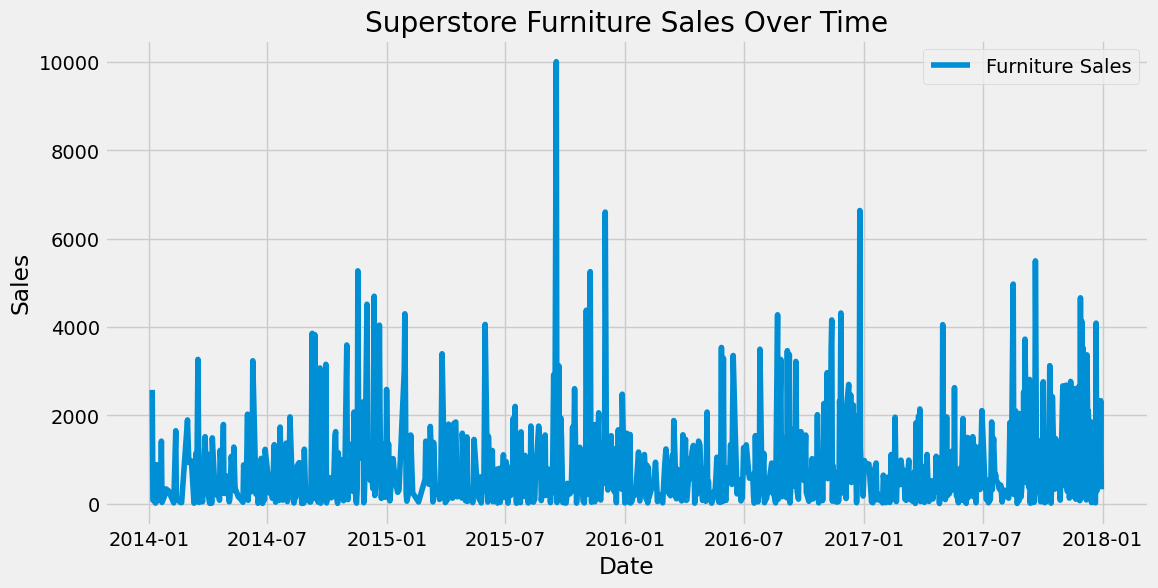

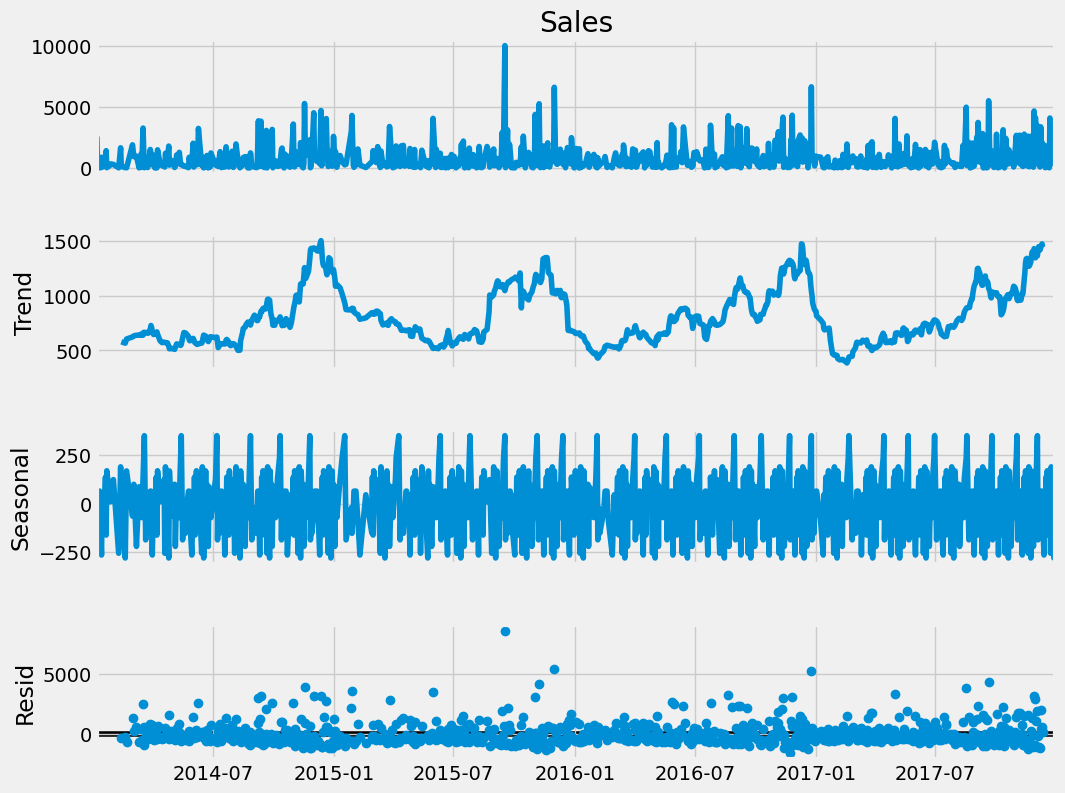

In [3]:
# AIM:
# The aim of performing time series analysis is to model and forecast the behavior
# of a time series data over a period of time, using statistical methods, in order
# to identify patterns, trends, and seasonality in the data.

# PROGRAM:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

# Load dataset
df = pd.read_excel("Sample - Superstore.xls")

# Filter only furniture sales
furniture = df.loc[df['Category'] == 'Furniture']

# Check time range
print("Date Range:", furniture['Order Date'].min(), "to", furniture['Order Date'].max())

# Drop unnecessary columns
cols = ['Row ID','Order ID','Ship Date','Ship Mode','Customer ID','Customer Name',
        'Segment','Country','City','State','Postal Code','Region','Product ID',
        'Category','Sub-Category','Product Name','Quantity','Discount','Profit']
furniture.drop(cols, axis=1, inplace=True)

# Sort values by date
furniture = furniture.sort_values('Order Date')

# Check for missing values
print("Missing values:\n", furniture.isnull().sum())

# Aggregate sales by order date
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()

# Convert to time series
furniture = furniture.set_index('Order Date')
print(furniture.head())

# Plot time series
plt.figure(figsize=(12,6))
plt.plot(furniture, label="Furniture Sales")
plt.title("Superstore Furniture Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Decomposition of time series (Trend, Seasonality, Residuals)
decomposition = sm.tsa.seasonal_decompose(furniture['Sales'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 9)
plt.show()


In [4]:
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import matplotlib

# Suppress warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use('fivethirtyeight')

# Configure matplotlib labels
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

# Load dataset
df = pd.read_excel("Sample - Superstore.xls")

# Filter furniture sales
furniture = df.loc[df['Category'] == 'Furniture']

# Check date range
print("Furniture sales date range:",
      furniture['Order Date'].min(),
      "to",
      furniture['Order Date'].max())


Furniture sales date range: 2014-01-06 00:00:00 to 2017-12-30 00:00:00


In [5]:
# Remove unnecessary columns
cols = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID',
        'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
        'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
        'Quantity', 'Discount', 'Profit']

furniture.drop(cols, axis=1, inplace=True)

# Sort values by order date
furniture = furniture.sort_values('Order Date')

# Check for missing values
print("Missing values:\n", furniture.isnull().sum())

# Aggregate sales by date
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()


Missing values:
 Order Date    0
Sales         0
dtype: int64


In [6]:
# Set 'Order Date' as the index
furniture = furniture.set_index('Order Date')

# Display the time series index
print(furniture.index)


DatetimeIndex(['2014-01-06', '2014-01-07', '2014-01-10', '2014-01-11',
               '2014-01-13', '2014-01-14', '2014-01-16', '2014-01-19',
               '2014-01-20', '2014-01-21',
               ...
               '2017-12-18', '2017-12-19', '2017-12-21', '2017-12-22',
               '2017-12-23', '2017-12-24', '2017-12-25', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=889, freq=None)


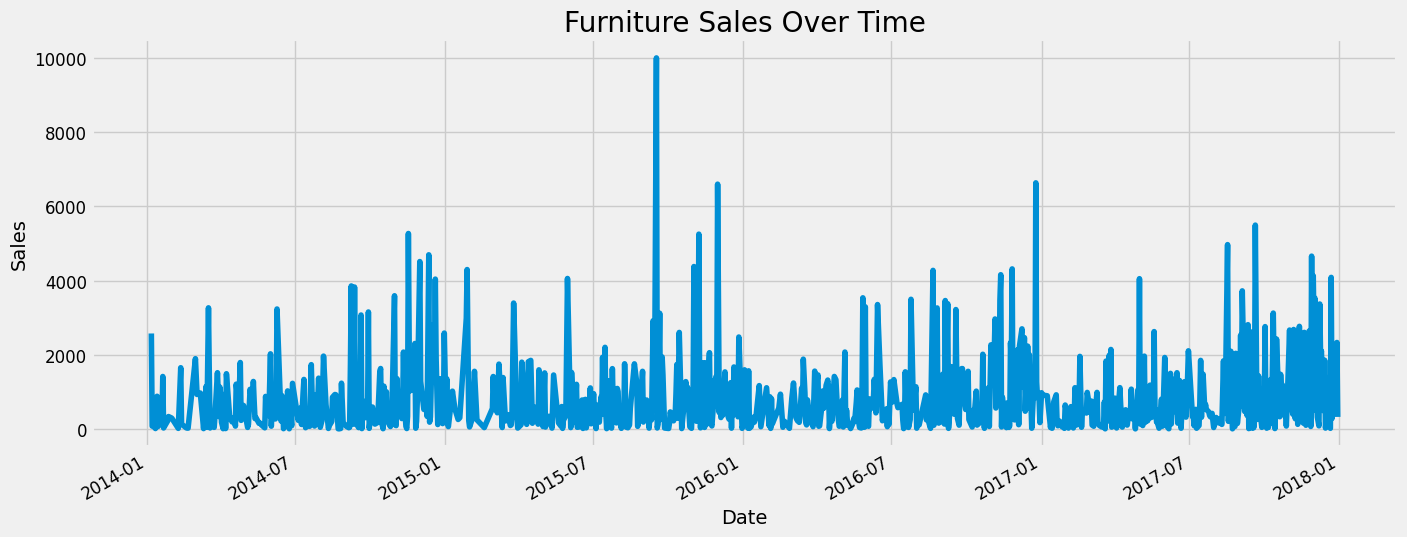

In [7]:
# Plot the furniture sales time series
furniture['Sales'].plot(figsize=(15,6))
plt.title("Furniture Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
